<link href="https://fonts.googleapis.com/css2?family=Oswald:wght@700&display=swap" rel="stylesheet">

<h1 style="
font-family: 'Oswald', sans-serif;
font-weight: 400;
font-style: italic;
font-size: 50px;
letter-spacing: 2px;
color: #E7C173;
text-shadow: 3px 3px 0 #333;
">
MACHINE LEARNING IN INDUSTRY <br> ASSIGNMENT DAY 1 & 2 <br> <br> Phase 2: Modeling
</h1>

In [1]:
from setup import *
RANDOM_STATE = 42

# ============================================================
# 0. Load data
# ============================================================
TRAIN_PATH = "data/train_clean.csv"
TEST_PATH = "data/test_clean.csv"

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

# ============================================================
# 1. Train / validation split
# ============================================================
X = train.drop(columns="target")
y = train["target"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("\nDefault rate — original:", y.mean(),
      "| train:", y_train.mean(),
      "| val:", y_val.mean())




# ============================================================
# 1b. Majority-class baseline (sanity check before any model)
# ============================================================
majority_class = y_train.mode()[0]
baseline_preds = np.full(len(y_val), majority_class)

baseline_accuracy = (y_val == majority_class).mean()

baseline_auc = roc_auc_score(y_val, baseline_preds)

print("Majority-class baseline accuracy:", round(baseline_accuracy, 4))
print("Majority-class baseline ROC-AUC:", round(baseline_auc, 4))

# ============================================================
# 2. Baseline model comparison
# ============================================================

# Calculate class ratio directly from training data
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f"scale_pos_weight = {scale_pos_weight:.4f}")


def build_models():
    return {

        "Logistic Regression": LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=RANDOM_STATE
        ),

        "Random Forest": RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=1
        ),

        "LightGBM": LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),

        # -------------------------
        # XGBoost (baseline)
        # -------------------------
        "XGBoost": XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            random_state=RANDOM_STATE,
            eval_metric="logloss"
        ),

        # -------------------------
        # XGBoost (weighted)
        # -------------------------
        "XGBoost Weighted": XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_STATE,
            eval_metric="logloss"
        ),

        # -------------------------
        # CatBoost (baseline)
        # -------------------------
        "CatBoost": CatBoostClassifier(
            iterations=300,
            learning_rate=0.05,
            depth=6,
            verbose=0,
            random_state=RANDOM_STATE
        ),

        # -------------------------
        # CatBoost (balanced)
        # -------------------------
        "CatBoost Balanced": CatBoostClassifier(
            iterations=300,
            learning_rate=0.05,
            depth=6,
            auto_class_weights="Balanced",
            verbose=0,
            random_state=RANDOM_STATE
        ),
    }

def run_cv(models, X_tr, y_tr, cv):
    rows = []
    for name, model in models.items():
        scores = cross_val_score(
            model, X_tr, y_tr, cv=cv, scoring="roc_auc", n_jobs=-1
        )
        rows.append([name, scores.mean(), scores.std()])
    return pd.DataFrame(rows, columns=["Model", "Mean ROC-AUC", "Std"]) \
             .sort_values("Mean ROC-AUC", ascending=False).round(4)


skf_5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
skf_10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)


cv_results_5 = run_cv(build_models(), X_train, y_train, skf_5)
print(f"\n{'5-fold CV results':^40}")
print(cv_results_5)

print(f"\n{'10-fold CV results':^40}")
cv_results_10 = run_cv(build_models(), X_train, y_train, skf_10)
print(cv_results_10)

Environment ready.
Train shape: (96112, 984)
Test shape: (23888, 983)
Training set: (76889, 983)
Validation set: (19223, 983)

Default rate — original: 0.14355127351423339 | train: 0.14355759601503465 | val: 0.1435259844977371
Majority-class baseline accuracy: 0.8565
Majority-class baseline ROC-AUC: 0.5
scale_pos_weight = 5.9658
[LightGBM] [Info] Number of positive: 8830, number of negative: 52681
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008842 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7295
[LightGBM] [Info] Number of data points in the train set: 61511, number of used features: 639
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Number of positive: 8830, number of negative: 52681
[LightGBM] [Info] Number of positive: 8831,

In [2]:
# ============================================================
# 2a. Compare baseline vs weighted variants
# ============================================================

auc_cat = cv_results_10.loc[
    cv_results_10["Model"] == "CatBoost",
    "Mean ROC-AUC"
].values[0]

auc_cat_balanced = cv_results_10.loc[
    cv_results_10["Model"] == "CatBoost Balanced",
    "Mean ROC-AUC"
].values[0]

auc_xgb = cv_results_10.loc[
    cv_results_10["Model"] == "XGBoost",
    "Mean ROC-AUC"
].values[0]

auc_xgb_weighted = cv_results_10.loc[
    cv_results_10["Model"] == "XGBoost Weighted",
    "Mean ROC-AUC"
].values[0]

results = pd.DataFrame({
    "Model": [
        "CatBoost",
        "CatBoost Balanced",
        "XGBoost",
        "XGBoost Weighted"
    ],
    "ROC_AUC": [
        auc_cat,
        auc_cat_balanced,
        auc_xgb,
        auc_xgb_weighted
    ]
})

print("\nWeighted-model comparison")
print(results.sort_values("ROC_AUC", ascending=False))


Weighted-model comparison
               Model  ROC_AUC
0           CatBoost   0.7001
1  CatBoost Balanced   0.6996
2            XGBoost   0.6979
3   XGBoost Weighted   0.6970


In [5]:
# ============================================================
# 3. Does SMOTE help CatBoost? (imblearn pipeline + manual CV
#    to confirm no leakage between folds)
# ============================================================
smote_pipe = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("model", CatBoostClassifier(
        iterations=300, learning_rate=0.05, depth=6,
        verbose=0, random_state=RANDOM_STATE
    )),
])

smote_auc_scores = cross_val_score(
    smote_pipe, X_train, y_train, cv=skf_10, scoring="roc_auc", n_jobs=-1
)

print("CatBoost + SMOTE — Mean ROC-AUC:", smote_auc_scores.mean().round(4),
      "Std:", smote_auc_scores.std().round(4))
print("CatBoost, no resampling — Mean ROC-AUC:",
      cv_results_10.loc[cv_results_10["Model"] == "CatBoost", "Mean ROC-AUC"].values[0])


def manual_cv_auc(build_model_fn, X_tr, y_tr, cv, resample=False):
    """Manual fold loop — needed to fit SMOTE only on each fold's
    training split (never on the validation fold)."""
    fold_aucs = []
    for train_idx, val_idx in cv.split(X_tr, y_tr):
        X_fold_train, X_fold_val = X_tr.iloc[train_idx], X_tr.iloc[val_idx]
        y_fold_train, y_fold_val = y_tr.iloc[train_idx], y_tr.iloc[val_idx]

        if resample:
            X_fold_train, y_fold_train = SMOTE(
                random_state=RANDOM_STATE
            ).fit_resample(X_fold_train, y_fold_train)

        model = build_model_fn()
        model.fit(X_fold_train, y_fold_train)
        val_probs = model.predict_proba(X_fold_val)[:, 1]
        fold_aucs.append(roc_auc_score(y_fold_val, val_probs))

    return np.array(fold_aucs)


smote_fold_aucs = manual_cv_auc(
    lambda: CatBoostClassifier(iterations=300, learning_rate=0.05, depth=6,
                                verbose=0, random_state=RANDOM_STATE),
    X_train, y_train, skf_10, resample=True
)
print("CatBoost + SMOTE (manual CV) — Mean ROC-AUC:", smote_fold_aucs.mean().round(4),
      "Std:", smote_fold_aucs.std().round(4))


CatBoost + SMOTE — Mean ROC-AUC: 0.6945 Std: 0.0053
CatBoost, no resampling — Mean ROC-AUC: 0.7001
CatBoost + SMOTE (manual CV) — Mean ROC-AUC: 0.6945 Std: 0.0053


In [6]:
# ============================================================
# 5. Hyperparameter search — one-hot encoded CatBoost
# ============================================================
param_grid = {
    "iterations": [200, 300, 500, 700],
    "depth": [4, 5, 6, 7, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "l2_leaf_reg": [1, 3, 5, 7, 9],
}

search = RandomizedSearchCV(
    estimator = CatBoostClassifier(
                iterations=300,
                learning_rate=0.05,
                depth=6,
                verbose=0,
                random_state=RANDOM_STATE
    ),
    param_distributions=param_grid,
    n_iter=30,
    scoring="roc_auc",
    cv=skf_10,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
search.fit(X_train, y_train)

best_params = search.best_params_
best_cat = search.best_estimator_
auc_score_tuned = search.best_score_
print(best_params, auc_score_tuned)

# ============================================================
# 6. Fit tuned model, validate, export val_submission.csv
# ============================================================
best_cat.fit(X_train, y_train)
val_probs = best_cat.predict_proba(X_val)[:, 1]
print("Validation ROC-AUC:", roc_auc_score(y_val, val_probs))

# X_val keeps the original train DataFrame index, so we can pull
# the matching row_id straight from the original train dataframe
val_row_ids = train.loc[X_val.index, "row_id"]

val_submission = pd.DataFrame({
    "row_id": val_row_ids,
    "predicted_probability": val_probs
})
val_submission.to_csv("val_submission.csv", index=False)

validation_labels = pd.DataFrame({
    "row_id": val_row_ids,
    "target": y_val
})
validation_labels.to_csv("validation_labels.csv", index=False)

print("Saved val_submission.csv:", val_submission.shape)
print("Saved validation_labels.csv:", validation_labels.shape)



{'learning_rate': 0.03, 'l2_leaf_reg': 3, 'iterations': 700, 'depth': 8} 0.7008253212273198
Validation ROC-AUC: 0.6953494764550049
Saved val_submission.csv: (19223, 2)
Saved validation_labels.csv: (19223, 2)


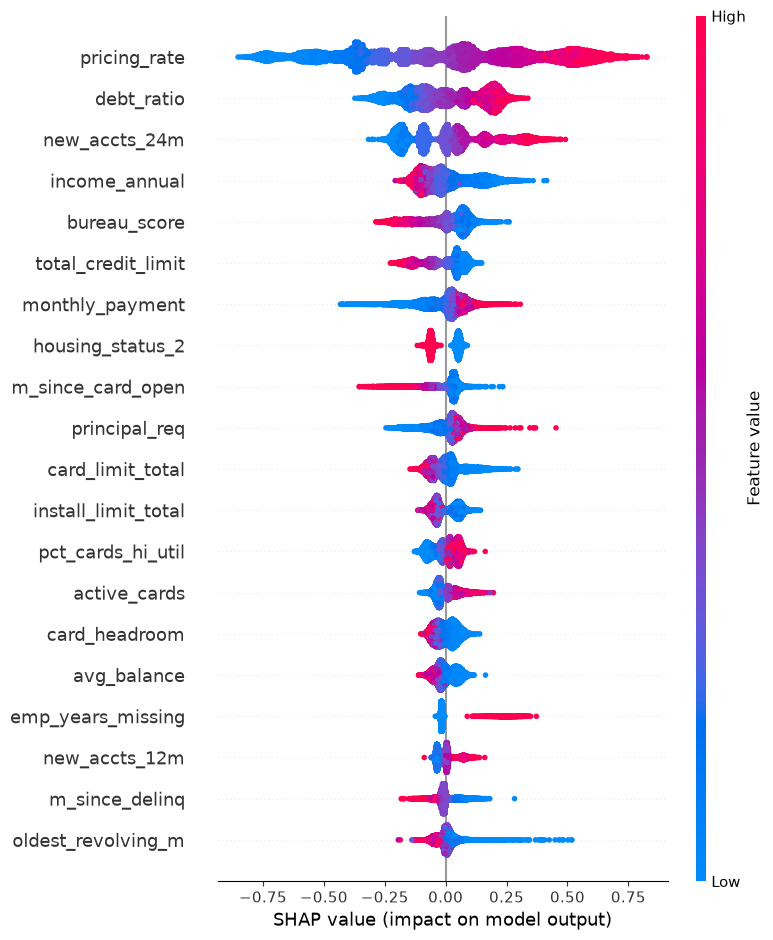

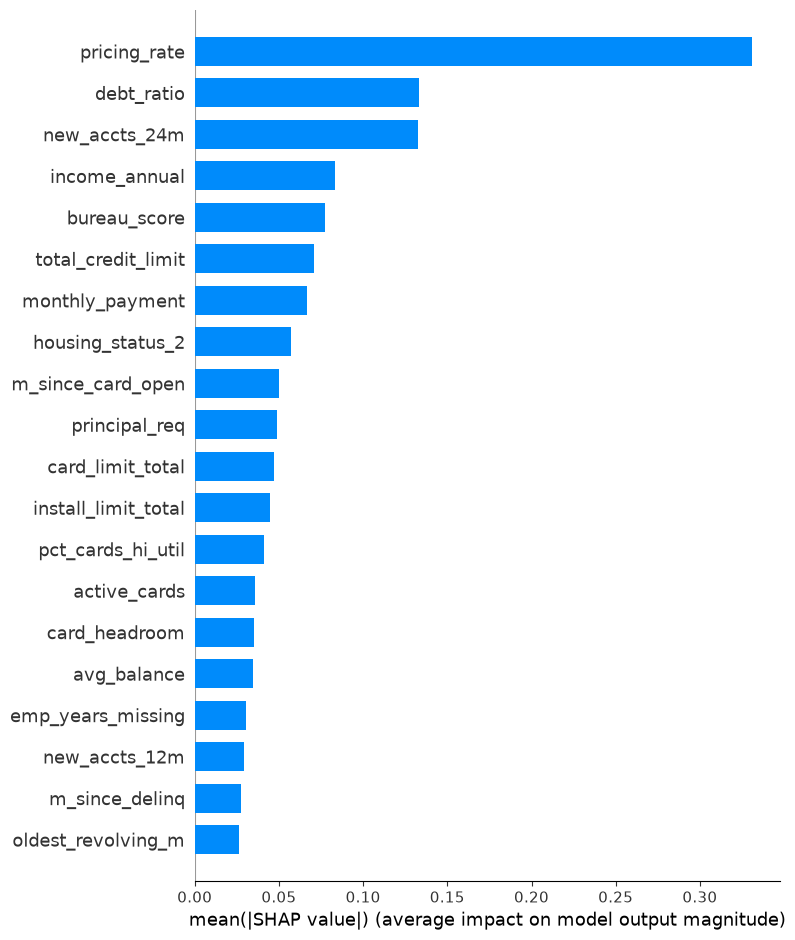

   Threshold  Precision  Recall      F1
0       0.05     0.1622  0.9706  0.2779
1       0.10     0.1963  0.8322  0.3177
2       0.15     0.2299  0.6401  0.3383
3       0.20     0.2606  0.4378  0.3267
4       0.25     0.3001  0.2773  0.2882
5       0.30     0.3242  0.1504  0.2055
6       0.40     0.3612  0.0297  0.0549
7       0.45     0.3375  0.0098  0.0190
8       0.50     0.4483  0.0047  0.0093
Best F1 threshold: 0.15


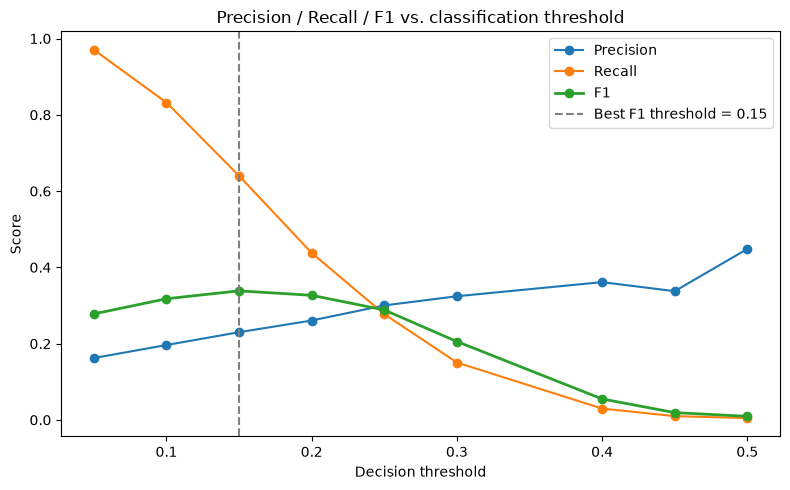

              precision    recall  f1-score   support

           0       0.91      0.64      0.75     16464
           1       0.23      0.64      0.34      2759

    accuracy                           0.64     19223
   macro avg       0.57      0.64      0.55     19223
weighted avg       0.82      0.64      0.69     19223



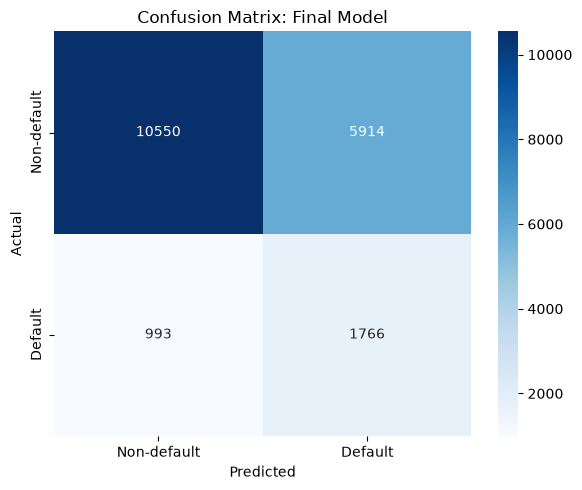

In [7]:
# ============================================================
# 7. SHAP explanations
# ============================================================
explainer = shap.TreeExplainer(best_cat)
shap_values = explainer.shap_values(X_val)

shap.summary_plot(shap_values, X_val, show=False)
plt.tight_layout()
plt.savefig("Figures/shap_summary_plot.pdf", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

shap.summary_plot(shap_values, X_val, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("Figures/shap_feature_importance_bar.pdf", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# ============================================================
# 8. Threshold analysis
# ============================================================
THRESHOLDS = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.45, 0.50]


def threshold_table(y_true, probs, thresholds=THRESHOLDS):
    rows = []
    for t in thresholds:
        pred = (probs >= t).astype(int)
        rows.append([
            t,
            precision_score(y_true, pred, zero_division=0),
            recall_score(y_true, pred, zero_division=0),
            f1_score(y_true, pred, zero_division=0),
        ])
    return pd.DataFrame(rows, columns=["Threshold", "Precision", "Recall", "F1"])


def plot_threshold_metrics(table, save_path):
    best_threshold = table.loc[table["F1"].idxmax(), "Threshold"]
    print("Best F1 threshold:", best_threshold)

    plt.figure(figsize=(8, 5))
    plt.plot(table["Threshold"], table["Precision"], marker="o", label="Precision")
    plt.plot(table["Threshold"], table["Recall"], marker="o", label="Recall")
    plt.plot(table["Threshold"], table["F1"], marker="o", label="F1", linewidth=2)
    plt.axvline(best_threshold, color="gray", linestyle="--",
                label=f"Best F1 threshold = {best_threshold}")
    plt.xlabel("Decision threshold")
    plt.ylabel("Score")
    plt.title("Precision / Recall / F1 vs. classification threshold")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    return best_threshold


threshold_results = threshold_table(y_val, val_probs)
print(threshold_results.round(4))

best_threshold = plot_threshold_metrics(
    threshold_results, os.path.join("Figures", "threshold_metrics.pdf")
)

val_preds = (val_probs >= best_threshold).astype(int)
print(classification_report(y_val, val_preds))

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_val, val_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-default", "Default"],
            yticklabels=["Non-default", "Default"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: Final Model")
plt.tight_layout()
plt.savefig(os.path.join("Figures", "confusion_matrix.pdf"), dpi=300, bbox_inches="tight")
plt.show()



In [8]:
# ============================================================
# 9. Retrain on ALL labeled data (train + val) and predict test
# ============================================================
X_full_enc = pd.concat([X_train, X_val], axis=0)
y_full = pd.concat([y_train, y_val], axis=0)
print("Full training set shape:", X_full_enc.shape)

final_cat = CatBoostClassifier(**best_params,
                verbose=0,
                random_state=RANDOM_STATE
    )

final_cat.fit(X_full_enc, y_full)
assert list(test.columns) == list(X_full_enc.columns), "Column mismatch!"

test_probs = final_cat.predict_proba(test)[:, 1]
submission = pd.DataFrame({
    "row_id": test["row_id"],
    "predicted_probability": test_probs
})

assert submission.shape[0] == 23888, "Row count mismatch!"
assert submission["row_id"].duplicated().sum() == 0, "Duplicate row_ids!"
assert submission["predicted_probability"].between(0, 1).all(), "Probabilities out of range!"
assert submission["row_id"].isin(test["row_id"]).all(), "Unknown row_ids!"

submission.to_csv("submission.csv", index=False)
print("Saved submission.csv")
print(submission.head())
print(submission["predicted_probability"].describe())

Full training set shape: (96112, 983)
Saved submission.csv
   row_id  predicted_probability
0      12               0.144036
1      16               0.191300
2      23               0.064482
3      25               0.070017
4      28               0.134276
count    23888.000000
mean         0.131424
std          0.086720
min          0.008368
25%          0.064681
50%          0.111365
75%          0.178657
max          0.614606
Name: predicted_probability, dtype: float64
